In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, matthews_corrcoef, cohen_kappa_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier


In [ ]:
df = pd.read_csv("/content/stroke_risk_dataset.csv")

X = df.drop(columns=["At Risk (Binary)", "Stroke Risk (%)"])
y = df["At Risk (Binary)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Naive Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss")
}


In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall (Sensitivity)": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Specificity": tn / (tn + fp),
        "MCC": matthews_corrcoef(y_test, y_pred),
        "Kappa": cohen_kappa_score(y_test, y_pred)
    })


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [03:45:39] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)
print(results_df)


                 Model  Accuracy  Precision  Recall (Sensitivity)  F1-Score  \
0  Logistic Regression  1.000000   1.000000              1.000000  1.000000   
9              XGBoost  0.996571   0.996122              0.998606  0.997363   
1                  SVM  0.991762   0.992247              0.995085  0.993664   
5             AdaBoost  0.985524   0.992317              0.985330  0.988811   
8                  LDA  0.977143   0.991407              0.973227  0.982233   
6    Gradient Boosting  0.960905   0.959607              0.981075  0.970222   
4        Random Forest  0.947810   0.954667              0.965451  0.960029   
7          Naive Bayes  0.927857   0.934088              0.956356  0.945091   
2                  KNN  0.896857   0.911092              0.932077  0.921465   
3        Decision Tree  0.883667   0.912854              0.907430  0.910134   

    ROC-AUC  Specificity       MCC     Kappa  
0  1.000000     1.000000  1.000000  1.000000  
9  0.999904     0.992806  0.992471  

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
    matthews_corrcoef, cohen_kappa_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier


In [ ]:
df = pd.read_csv("/content/stroke_risk_dataset.csv")

X = df.drop(columns=["At Risk (Binary)", "Stroke Risk (%)"])
y = df["At Risk (Binary)"]

feature_names = X.columns.tolist()
n_features = len(feature_names)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [ ]:
population_size = 20
max_iter = 30
beta = 0.5
np.random.seed(42)

population = np.random.randint(0, 2, (population_size, n_features))

def fitness(mask):
    if mask.sum() == 0:
        return 0
    model = LogisticRegression(max_iter=2000)
    model.fit(X_train.iloc[:, mask == 1], y_train)
    preds = model.predict(X_test.iloc[:, mask == 1])
    return accuracy_score(y_test, preds)

fitness_vals = np.array([fitness(ind) for ind in population])
best_solution = population[np.argmax(fitness_vals)]

for _ in range(max_iter):
    for i in range(population_size):
        r = np.random.rand()
        if r < beta:
            new_sol = population[i] + np.random.randint(-1, 2, n_features)
        else:
            new_sol = population[i] + np.random.rand() * (best_solution - population[i])

        new_sol = (1 / (1 + np.exp(-new_sol)) > 0.5).astype(int)
        new_fit = fitness(new_sol)

        if new_fit > fitness_vals[i]:
            population[i] = new_sol
            fitness_vals[i] = new_fit

    best_solution = population[np.argmax(fitness_vals)]

selected_features = [feature_names[i] for i in range(n_features) if best_solution[i] == 1]

print("CLOA Selected Features:")
print(selected_features)


CLOA Selected Features:
['Chest Pain', 'Shortness of Breath', 'Irregular Heartbeat', 'Fatigue & Weakness', 'Dizziness', 'Swelling (Edema)', 'Pain in Neck/Jaw/Shoulder/Back', 'Excessive Sweating', 'Persistent Cough', 'Nausea/Vomiting', 'High Blood Pressure', 'Chest Discomfort (Activity)', 'Cold Hands/Feet', 'Snoring/Sleep Apnea', 'Anxiety/Feeling of Doom', 'Age']



Feature Ranking after CLOA:
                           Feature  Importance Score
15                             Age          0.512616
6   Pain in Neck/Jaw/Shoulder/Back          0.034081
2              Irregular Heartbeat          0.033845
5                 Swelling (Edema)          0.033818
9                  Nausea/Vomiting          0.033444
11     Chest Discomfort (Activity)          0.033257
1              Shortness of Breath          0.032966
14         Anxiety/Feeling of Doom          0.032961
4                        Dizziness          0.032178
8                 Persistent Cough          0.032043
3               Fatigue & Weakness          0.032013
10             High Blood Pressure          0.031958
13             Snoring/Sleep Apnea          0.031662
7               Excessive Sweating          0.031633
0                       Chest Pain          0.031370
12                 Cold Hands/Feet          0.030156


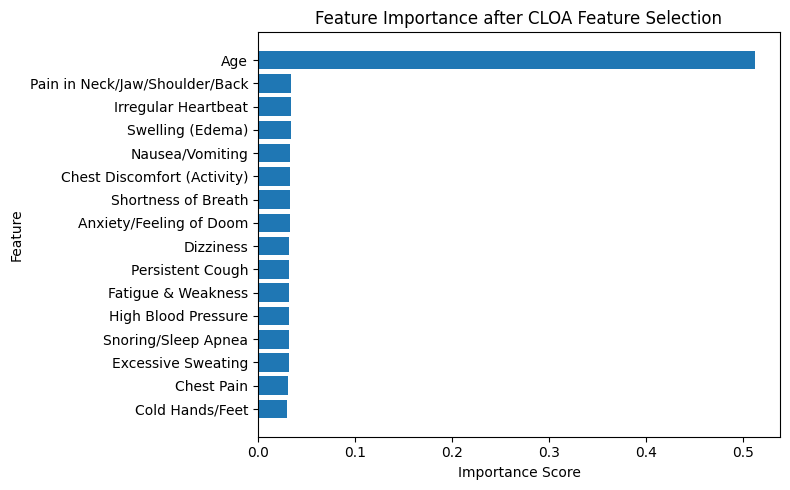

In [ ]:
X_train_fs = X_train[selected_features]
X_test_fs = X_test[selected_features]

scaler = StandardScaler()
X_train_fs = scaler.fit_transform(X_train_fs)
X_test_fs = scaler.transform(X_test_fs)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_fs, y_train)

importance_df = pd.DataFrame({
    "Feature": selected_features,
    "Importance Score": rf.feature_importances_
}).sort_values(by="Importance Score", ascending=False)

print("\nFeature Ranking after CLOA:")
print(importance_df)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(importance_df["Feature"], importance_df["Importance Score"])
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance after CLOA Feature Selection")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Naive Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss")
}


In [ ]:
def evaluate_models(Xtr, Xte, title):
    results = []

    for name, model in models.items():
        model.fit(Xtr, y_train)
        y_pred = model.predict(Xte)
        y_prob = model.predict_proba(Xte)[:, 1]

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-Score": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_prob),
            "Specificity": tn / (tn + fp),
            "MCC": matthews_corrcoef(y_test, y_pred),
            "Kappa": cohen_kappa_score(y_test, y_pred)
        })

    df_results = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
    print(f"\n{title}")
    print(df_results)
    return df_results


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results_without_fs = evaluate_models(
    X_train_scaled, X_test_scaled,
    "Results WITHOUT Feature Selection"
)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:21:19] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Results WITHOUT Feature Selection
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC  \
0  Logistic Regression  1.000000   1.000000  1.000000  1.000000  1.000000   
9              XGBoost  0.996571   0.996122  0.998606  0.997363  0.999904   
1                  SVM  0.991762   0.992247  0.995085  0.993664  0.999751   
5             AdaBoost  0.985524   0.992317  0.985330  0.988811  0.999341   
8                  LDA  0.977143   0.991407  0.973227  0.982233  0.998709   
6    Gradient Boosting  0.960905   0.959607  0.981075  0.970222  0.991946   
4        Random Forest  0.947762   0.954994  0.965011  0.959977  0.990697   
7          Naive Bayes  0.927857   0.934088  0.956356  0.945091  0.977600   
2                  KNN  0.896857   0.911092  0.932077  0.921465  0.957186   
3        Decision Tree  0.883571   0.913390  0.906624  0.909994  0.873768   

   Specificity       MCC     Kappa  
0     1.000000  1.000000  1.000000  
9     0.992806  0.992471  0.992465  
1     

In [ ]:
results_with_fs = evaluate_models(
    X_train_fs, X_test_fs,
    "Results WITH CLOA Feature Selection"
)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:25:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Results WITH CLOA Feature Selection
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC  \
0  Logistic Regression  1.000000   1.000000  1.000000  1.000000  1.000000   
9              XGBoost  0.996571   0.996122  0.998606  0.997363  0.999904   
1                  SVM  0.991762   0.992247  0.995085  0.993664  0.999751   
5             AdaBoost  0.985524   0.992317  0.985330  0.988811  0.999341   
8                  LDA  0.977143   0.991407  0.973227  0.982233  0.998709   
6    Gradient Boosting  0.960905   0.959607  0.981075  0.970222  0.991946   
4        Random Forest  0.946714   0.953603  0.964865  0.959201  0.990824   
7          Naive Bayes  0.927857   0.934088  0.956356  0.945091  0.977600   
2                  KNN  0.896857   0.911092  0.932077  0.921465  0.957186   
3        Decision Tree  0.883714   0.912617  0.907797  0.910201  0.873472   

   Specificity       MCC     Kappa  
0     1.000000  1.000000  1.000000  
9     0.992806  0.992471  0.992465  
1   

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
    matthews_corrcoef, cohen_kappa_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB


In [ ]:
df = pd.read_csv("/content/stroke_risk_dataset.csv")

X = df.drop(columns=["At Risk (Binary)", "Stroke Risk (%)"])
y = df["At Risk (Binary)"]

feature_names = X.columns.tolist()
n_features = len(feature_names)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [ ]:
population_size = 20
max_iter = 25
beta = 0.5
np.random.seed(42)

population = np.random.randint(0, 2, (population_size, n_features))

def fitness(mask):
    if mask.sum() != 8:   # 🔴 force exactly 8 features
        return 0
    model = LogisticRegression(max_iter=2000)
    model.fit(X_train.iloc[:, mask == 1], y_train)
    preds = model.predict(X_test.iloc[:, mask == 1])
    return accuracy_score(y_test, preds)

fitness_vals = np.array([fitness(ind) for ind in population])
best_solution = population[np.argmax(fitness_vals)]

for _ in range(max_iter):
    for i in range(population_size):
        r = np.random.rand()

        if r < beta:
            new_sol = population[i] + np.random.randint(-1, 2, n_features)
        else:
            new_sol = population[i] + np.random.rand() * (best_solution - population[i])

        new_sol = (1 / (1 + np.exp(-new_sol)) > 0.5).astype(int)

        if new_sol.sum() != 8:
            continue

        new_fit = fitness(new_sol)
        if new_fit > fitness_vals[i]:
            population[i] = new_sol
            fitness_vals[i] = new_fit

    best_solution = population[np.argmax(fitness_vals)]

selected_features = [feature_names[i] for i in range(n_features) if best_solution[i] == 1]

print("✅ CLOA Selected 8 Features:")
print(selected_features)


✅ CLOA Selected 8 Features:
['Irregular Heartbeat', 'Dizziness', 'Swelling (Edema)', 'Pain in Neck/Jaw/Shoulder/Back', 'Nausea/Vomiting', 'High Blood Pressure', 'Cold Hands/Feet', 'Age']



📊 Feature Importance Scores:
                          Feature  Importance Score
7                             Age          0.763572
6                 Cold Hands/Feet          0.034752
1                       Dizziness          0.034214
5             High Blood Pressure          0.033759
0             Irregular Heartbeat          0.033747
4                 Nausea/Vomiting          0.033696
3  Pain in Neck/Jaw/Shoulder/Back          0.033476
2                Swelling (Edema)          0.032784


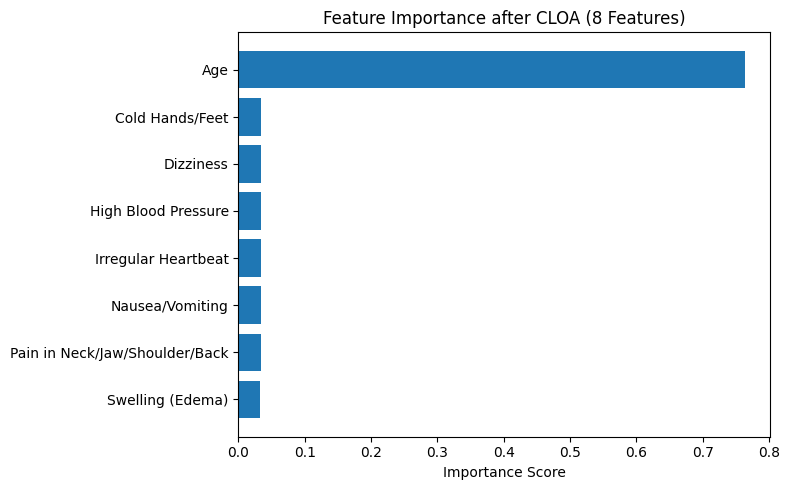

In [ ]:
X_train_fs = X_train[selected_features]
X_test_fs = X_test[selected_features]

scaler = StandardScaler()
X_train_fs = scaler.fit_transform(X_train_fs)
X_test_fs = scaler.transform(X_test_fs)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_fs, y_train)

importance_df = pd.DataFrame({
    "Feature": selected_features,
    "Importance Score": rf.feature_importances_
}).sort_values(by="Importance Score", ascending=False)

print("\n📊 Feature Importance Scores:")
print(importance_df)

# Plot
plt.figure(figsize=(8, 5))
plt.barh(importance_df["Feature"], importance_df["Importance Score"])
plt.xlabel("Importance Score")
plt.title("Feature Importance after CLOA (8 Features)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Naive Bayes": GaussianNB()
}


In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train_fs, y_train)
    y_pred = model.predict(X_test_fs)
    y_prob = model.predict_proba(X_test_fs)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Specificity": tn / (tn + fp),
        "MCC": matthews_corrcoef(y_test, y_pred),
        "Kappa": cohen_kappa_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print("\n📈 Model Performance using CLOA Selected Features:")
print(results_df)



📈 Model Performance using CLOA Selected Features:
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC  \
6    Gradient Boosting  0.867524   0.894438  0.902443  0.898423  0.933610   
0  Logistic Regression  0.867048   0.892363  0.904276  0.898280  0.933348   
5             AdaBoost  0.863714   0.891075  0.900095  0.895563  0.933000   
1                  SVM  0.860667   0.882584  0.905890  0.894085  0.924308   
7          Naive Bayes  0.847619   0.886551  0.877576  0.882041  0.922170   
2                  KNN  0.839952   0.874399  0.879850  0.877116  0.899781   
4        Random Forest  0.838048   0.873758  0.877283  0.875517  0.906595   
3        Decision Tree  0.835143   0.884537  0.858065  0.871100  0.893275   

   Specificity       MCC     Kappa  
6     0.802905  0.708100  0.708042  
0     0.798154  0.706570  0.706441  
5     0.796389  0.699569  0.699496  
1     0.776978  0.691125  0.690624  
7     0.792181  0.666956  0.666887  
2     0.766119  0.647713  0.64768

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
    matthews_corrcoef, cohen_kappa_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB


In [ ]:
df = pd.read_csv("/content/stroke_risk_dataset.csv")

X = df.drop(columns=["At Risk (Binary)", "Stroke Risk (%)"])
y = df["At Risk (Binary)"]

feature_names = X.columns.tolist()
n_features = len(feature_names)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [ ]:
population_size = 20
max_iter = 25
beta = 0.5
np.random.seed(42)

population = np.random.randint(0, 2, (population_size, n_features))

def fitness(mask):
    if mask.sum() != 8:
        return 0
    model = LogisticRegression(max_iter=2000)
    model.fit(X_train.iloc[:, mask == 1], y_train)
    preds = model.predict(X_test.iloc[:, mask == 1])
    return accuracy_score(y_test, preds)

fitness_vals = np.array([fitness(ind) for ind in population])
best_solution = population[np.argmax(fitness_vals)]

for _ in range(max_iter):
    for i in range(population_size):
        r = np.random.rand()
        if r < beta:
            new_sol = population[i] + np.random.randint(-1, 2, n_features)
        else:
            new_sol = population[i] + np.random.rand() * (best_solution - population[i])

        new_sol = (1 / (1 + np.exp(-new_sol)) > 0.5).astype(int)
        if new_sol.sum() != 8:
            continue

        new_fit = fitness(new_sol)
        if new_fit > fitness_vals[i]:
            population[i] = new_sol
            fitness_vals[i] = new_fit

    best_solution = population[np.argmax(fitness_vals)]

selected_features = [feature_names[i] for i in range(n_features) if best_solution[i] == 1]

print("✅ CLOA Selected Features:", selected_features)


✅ CLOA Selected Features: ['Irregular Heartbeat', 'Dizziness', 'Swelling (Edema)', 'Pain in Neck/Jaw/Shoulder/Back', 'Nausea/Vomiting', 'High Blood Pressure', 'Cold Hands/Feet', 'Age']


In [ ]:
scaler_full = StandardScaler()
X_train_full = scaler_full.fit_transform(X_train)
X_test_full = scaler_full.transform(X_test)

X_train_fs = X_train[selected_features]
X_test_fs = X_test[selected_features]

scaler_fs = StandardScaler()
X_train_fs = scaler_fs.fit_transform(X_train_fs)
X_test_fs = scaler_fs.transform(X_test_fs)


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Naive Bayes": GaussianNB()
}


In [ ]:
def evaluate(Xtr, Xte, title):
    results = []

    for name, model in models.items():
        model.fit(Xtr, y_train)
        y_pred = model.predict(Xte)
        y_prob = model.predict_proba(Xte)[:, 1]

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-Score": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_prob),
            "Specificity": tn / (tn + fp),
            "MCC": matthews_corrcoef(y_test, y_pred),
            "Kappa": cohen_kappa_score(y_test, y_pred)
        })

    df_results = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
    print(f"\n📊 {title}")
    print(df_results)
    return df_results


In [ ]:
results_without_fs = evaluate(
    X_train_full, X_test_full,
    "Results WITHOUT Feature Selection"
)



📊 Results WITHOUT Feature Selection
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC  \
0  Logistic Regression  1.000000   1.000000  1.000000  1.000000  1.000000   
1                  SVM  0.991762   0.992247  0.995085  0.993664  0.999751   
5             AdaBoost  0.985524   0.992317  0.985330  0.988811  0.999341   
6    Gradient Boosting  0.960905   0.959607  0.981075  0.970222  0.991946   
4        Random Forest  0.948143   0.955218  0.965378  0.960271  0.990583   
7          Naive Bayes  0.927857   0.934088  0.956356  0.945091  0.977600   
2                  KNN  0.896857   0.911092  0.932077  0.921465  0.957186   
3        Decision Tree  0.883619   0.913397  0.906697  0.910035  0.873805   

   Specificity       MCC     Kappa  
0     1.000000  1.000000  1.000000  
1     0.985612  0.981900  0.981892  
5     0.985883  0.968361  0.968313  
6     0.923578  0.913817  0.913343  
4     0.916248  0.885735  0.885632  
7     0.875119  0.840486  0.839991  
2     0.83

In [ ]:
results_with_fs = evaluate(
    X_train_fs, X_test_fs,
    "Results WITH CLOA Feature Selection"
)



📊 Results WITH CLOA Feature Selection
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC  \
6    Gradient Boosting  0.867524   0.894438  0.902443  0.898423  0.933610   
0  Logistic Regression  0.867048   0.892363  0.904276  0.898280  0.933348   
5             AdaBoost  0.863714   0.891075  0.900095  0.895563  0.933000   
1                  SVM  0.860667   0.882584  0.905890  0.894085  0.924307   
7          Naive Bayes  0.847619   0.886551  0.877576  0.882041  0.922170   
2                  KNN  0.839952   0.874399  0.879850  0.877116  0.899781   
4        Random Forest  0.839048   0.874881  0.877576  0.876227  0.906513   
3        Decision Tree  0.835143   0.884537  0.858065  0.871100  0.893275   

   Specificity       MCC     Kappa  
6     0.802905  0.708100  0.708042  
0     0.798154  0.706570  0.706441  
5     0.796389  0.699569  0.699496  
1     0.776978  0.691125  0.690624  
7     0.792181  0.666956  0.666887  
2     0.766119  0.647713  0.647687  
4     0.

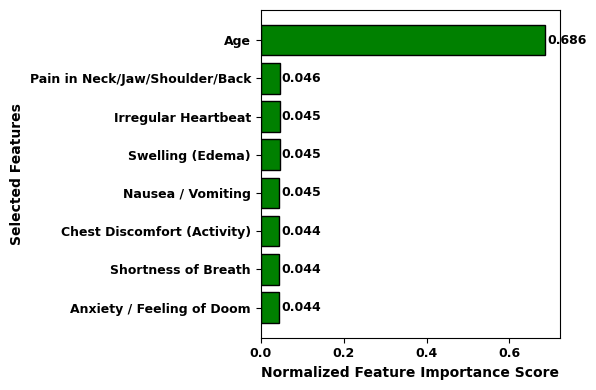

In [ ]:
import matplotlib.pyplot as plt

# Feature names and normalized scores
features = [
    "Age",
    "Pain in Neck/Jaw/Shoulder/Back",
    "Irregular Heartbeat",
    "Swelling (Edema)",
    "Nausea / Vomiting",
    "Chest Discomfort (Activity)",
    "Shortness of Breath",
    "Anxiety / Feeling of Doom"
]

scores = [0.6864, 0.0456, 0.0453, 0.0453, 0.0448, 0.0445, 0.0441, 0.0441]

# Figure size
fig_width, fig_height = 6, 4
plt.figure(figsize=(fig_width, fig_height))

# Dynamic font scaling based on figure size
base_font = fig_width * 1.5   # automatic scaling

# Horizontal bar plot
bars = plt.barh(
    features,
    scores,
    color="green",
    edgecolor="black"
)

# Invert y-axis
plt.gca().invert_yaxis()

# Add value labels (bold & dark)
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=base_font,
        fontweight="bold",
        color="black"
    )

# Axis labels (bold & dark)
plt.xlabel(
    "Normalized Feature Importance Score",
    fontsize=base_font + 1,
    fontweight="bold",
    color="black"
)

plt.ylabel(
    "Selected Features",
    fontsize=base_font + 1,
    fontweight="bold",
    color="black"
)

# Make tick labels bold & dark
plt.xticks(fontsize=base_font, fontweight="bold", color="black")
plt.yticks(fontsize=base_font, fontweight="bold", color="black")

# Tight layout
plt.tight_layout()

# Save high-resolution figure
plt.savefig(
    "Stroke_Feature_Importance_Top8.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


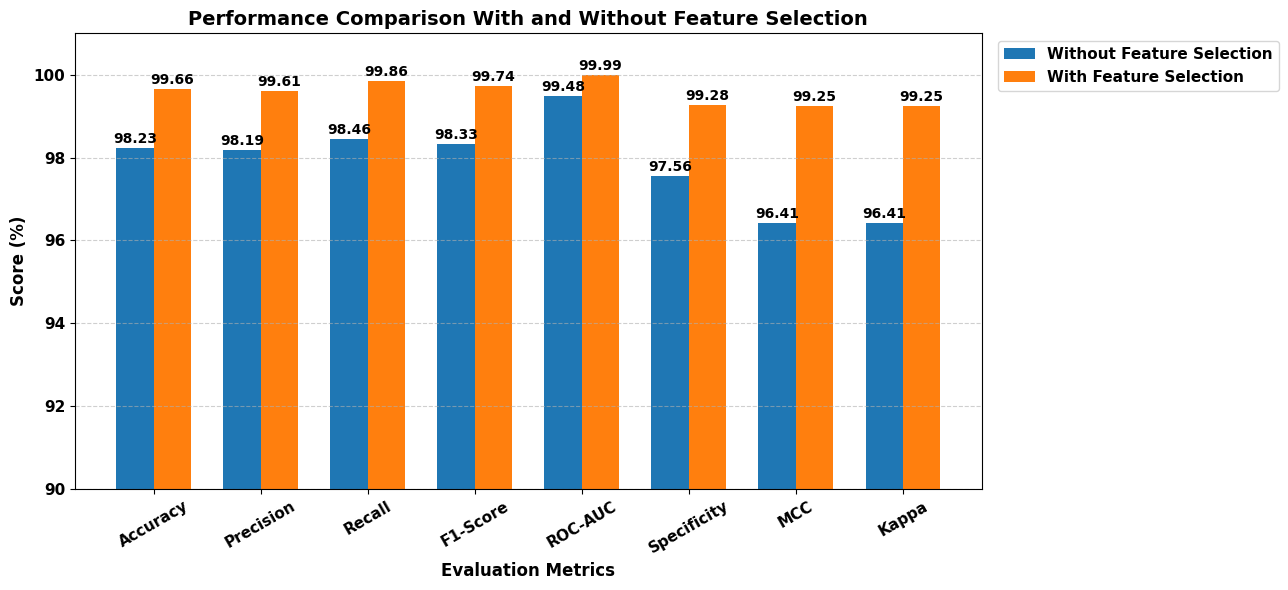

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Metrics
metrics = [
    "Accuracy", "Precision", "Recall", "F1-Score",
    "ROC-AUC", "Specificity", "MCC", "Kappa"
]

# Values (percentage)
without_fs = [98.23, 98.19, 98.46, 98.33, 99.48, 97.56, 96.41, 96.41]
with_fs    = [99.66, 99.61, 99.86, 99.74, 99.99, 99.28, 99.25, 99.25]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(13, 6))

bars1 = plt.bar(x - width/2, without_fs, width, label="Without Feature Selection")
bars2 = plt.bar(x + width/2, with_fs, width, label="With Feature Selection")

# Value labels (BOLD)
for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.12,
        f"{bar.get_height():.2f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.12,
        f"{bar.get_height():.2f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# Axis labels and ticks (BOLD)
plt.xticks(x, metrics, rotation=30, fontsize=11, fontweight="bold")
plt.yticks(fontsize=11, fontweight="bold")
plt.ylabel("Score (%)", fontsize=12, fontweight="bold")
plt.xlabel("Evaluation Metrics", fontsize=12, fontweight="bold")

# Title (BOLD)
plt.title(
    "Performance Comparison With and Without Feature Selection",
    fontsize=14,
    fontweight="bold"
)

plt.ylim(90, 101)

# Legend (BOLD, moved outside)
legend = plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    prop={"weight": "bold", "size": 11}
)

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


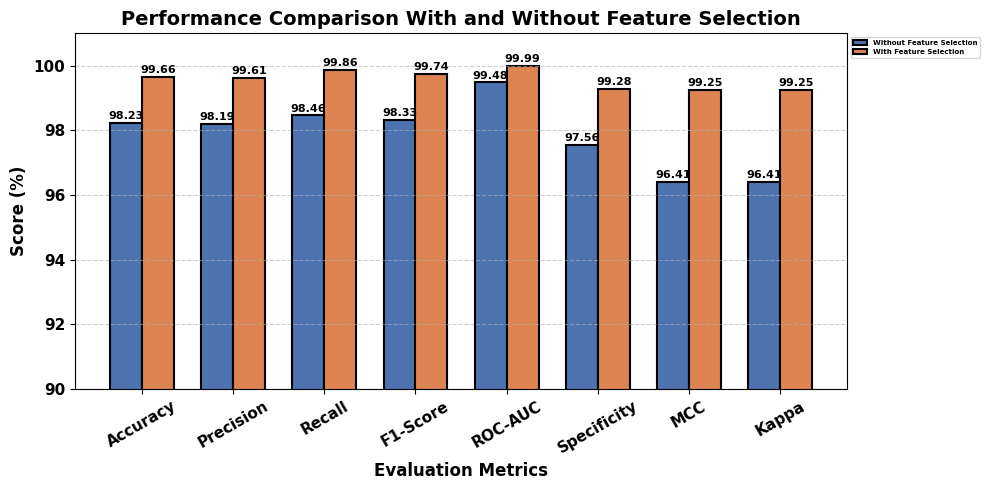

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Metrics
metrics = [
    "Accuracy", "Precision", "Recall", "F1-Score",
    "ROC-AUC", "Specificity", "MCC", "Kappa"
]

# Values (percentage)
without_fs = [98.23, 98.19, 98.46, 98.33, 99.48, 97.56, 96.41, 96.41]
with_fs    = [99.66, 99.61, 99.86, 99.74, 99.99, 99.28, 99.25, 99.25]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 5))

# 🔹 BAR COLORS + OUTLINE COLORS
bars1 = plt.bar(
    x - width/2,
    without_fs,
    width,
    label="Without Feature Selection",
    color="#4C72B0",        # blue fill
    edgecolor="black",      # outline
    linewidth=1.5
)

bars2 = plt.bar(
    x + width/2,
    with_fs,
    width,
    label="With Feature Selection",
    color="#DD8452",        # orange fill
    edgecolor="black",      # outline
    linewidth=1.5
)

# Value labels (BOLD)
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.12,
             f"{bar.get_height():.2f}",
             ha="center", fontsize=8, fontweight="bold")

for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.12,
             f"{bar.get_height():.2f}",
             ha="center", fontsize=8, fontweight="bold")

# Axis labels and ticks (BOLD)
plt.xticks(x, metrics, rotation=30, fontsize=11, fontweight="bold")
plt.yticks(fontsize=11, fontweight="bold")
plt.ylabel("Score (%)", fontsize=12, fontweight="bold")
plt.xlabel("Evaluation Metrics", fontsize=12, fontweight="bold")

# Title (BOLD)
plt.title(
    "Performance Comparison With and Without Feature Selection",
    fontsize=14,
    fontweight="bold"
)

plt.ylim(90, 101)

# Legend (BOLD, outside)
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    prop={"weight": "bold", "size": 5}
)

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.tight_layout()

# Save high-resolution figure
plt.savefig(
    "aa.png",
    dpi=300,
    bbox_inches="tight")
plt.show()


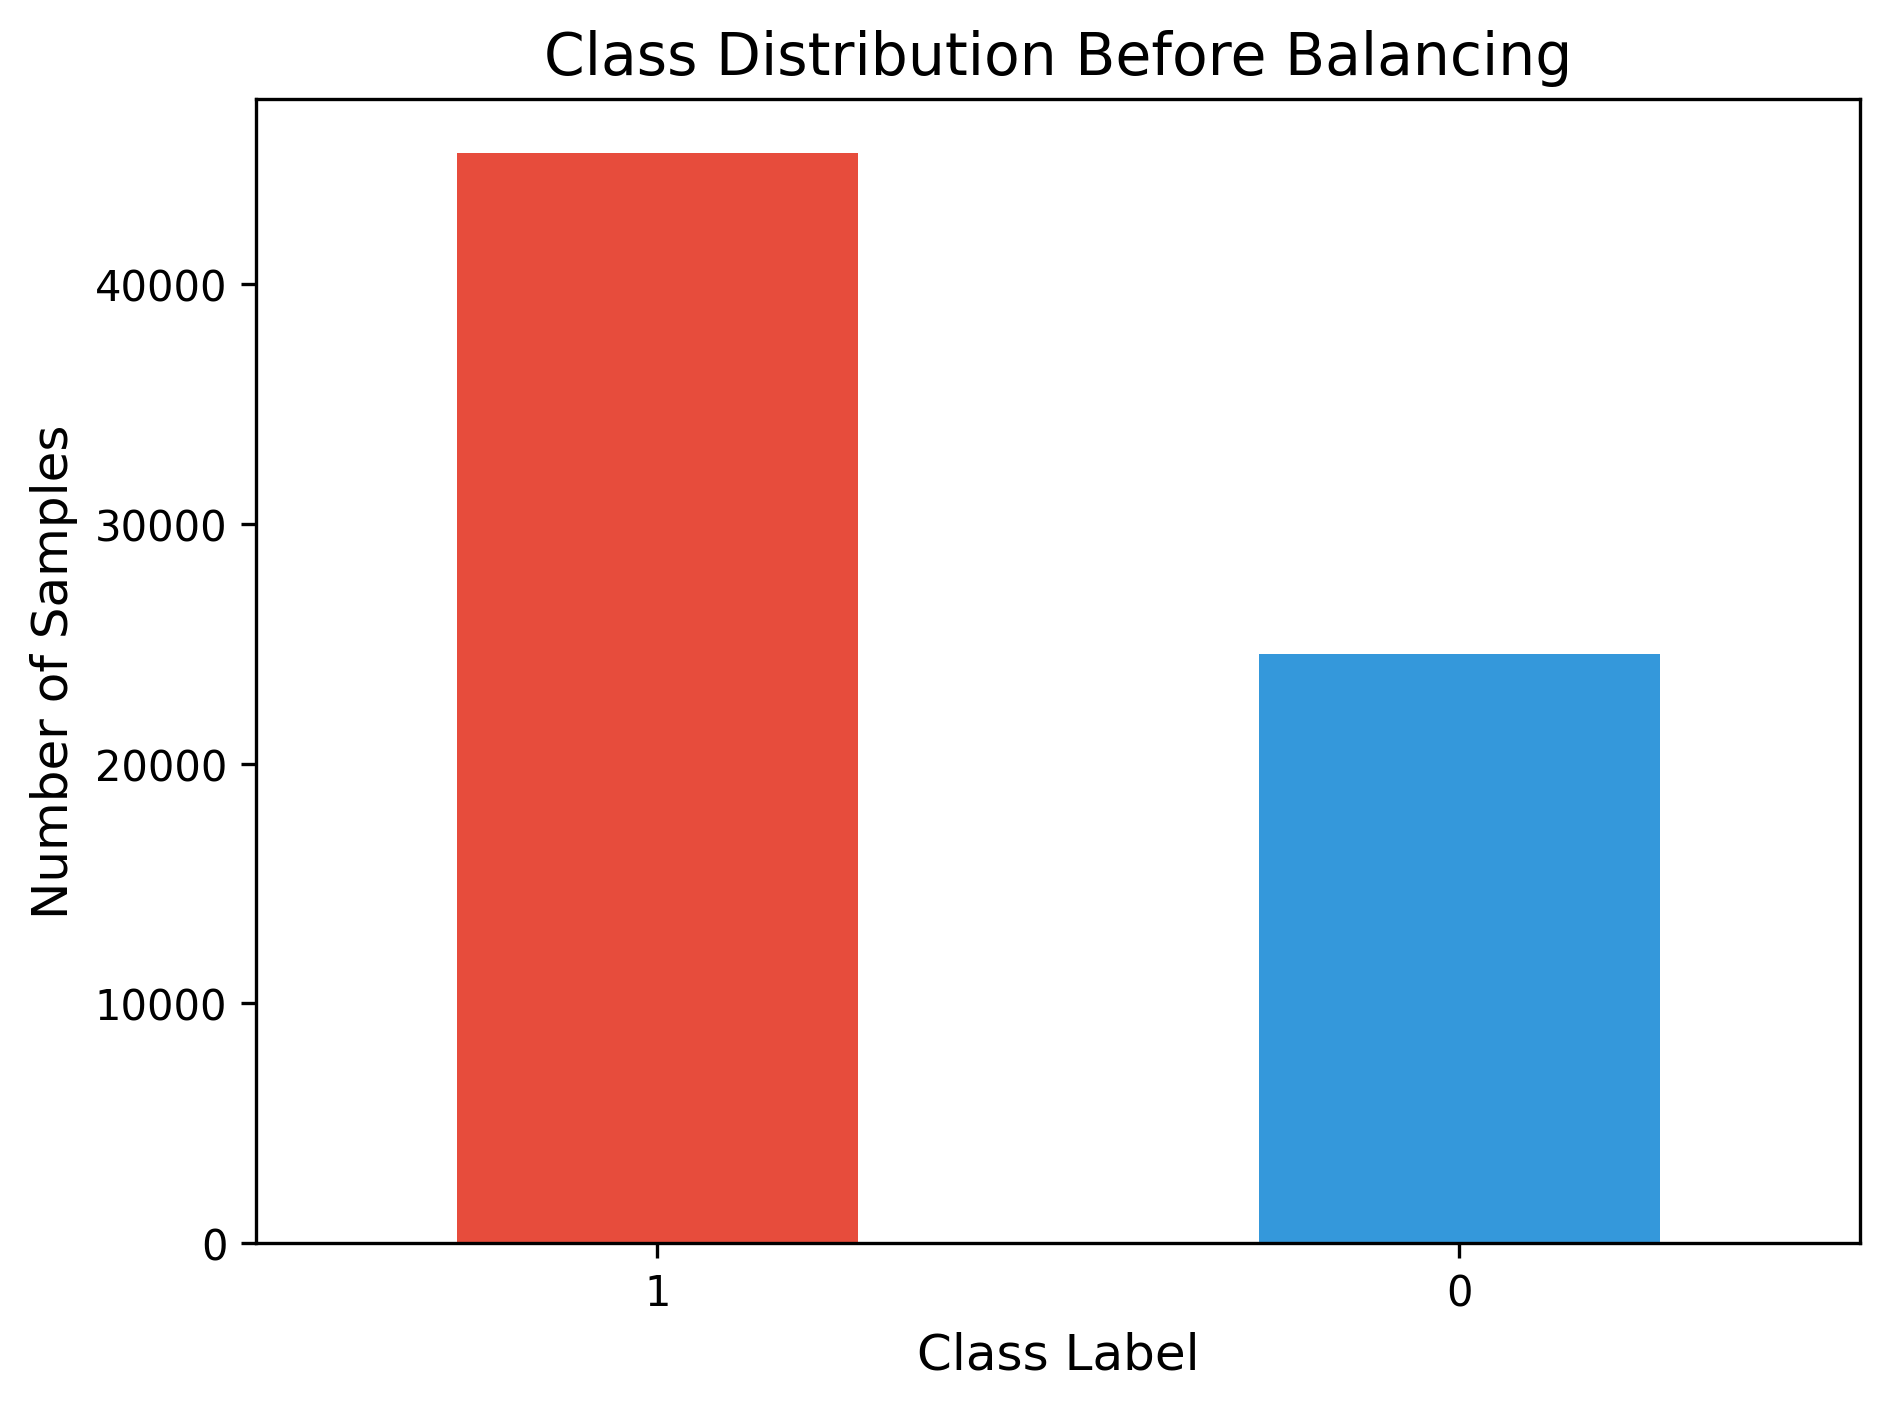

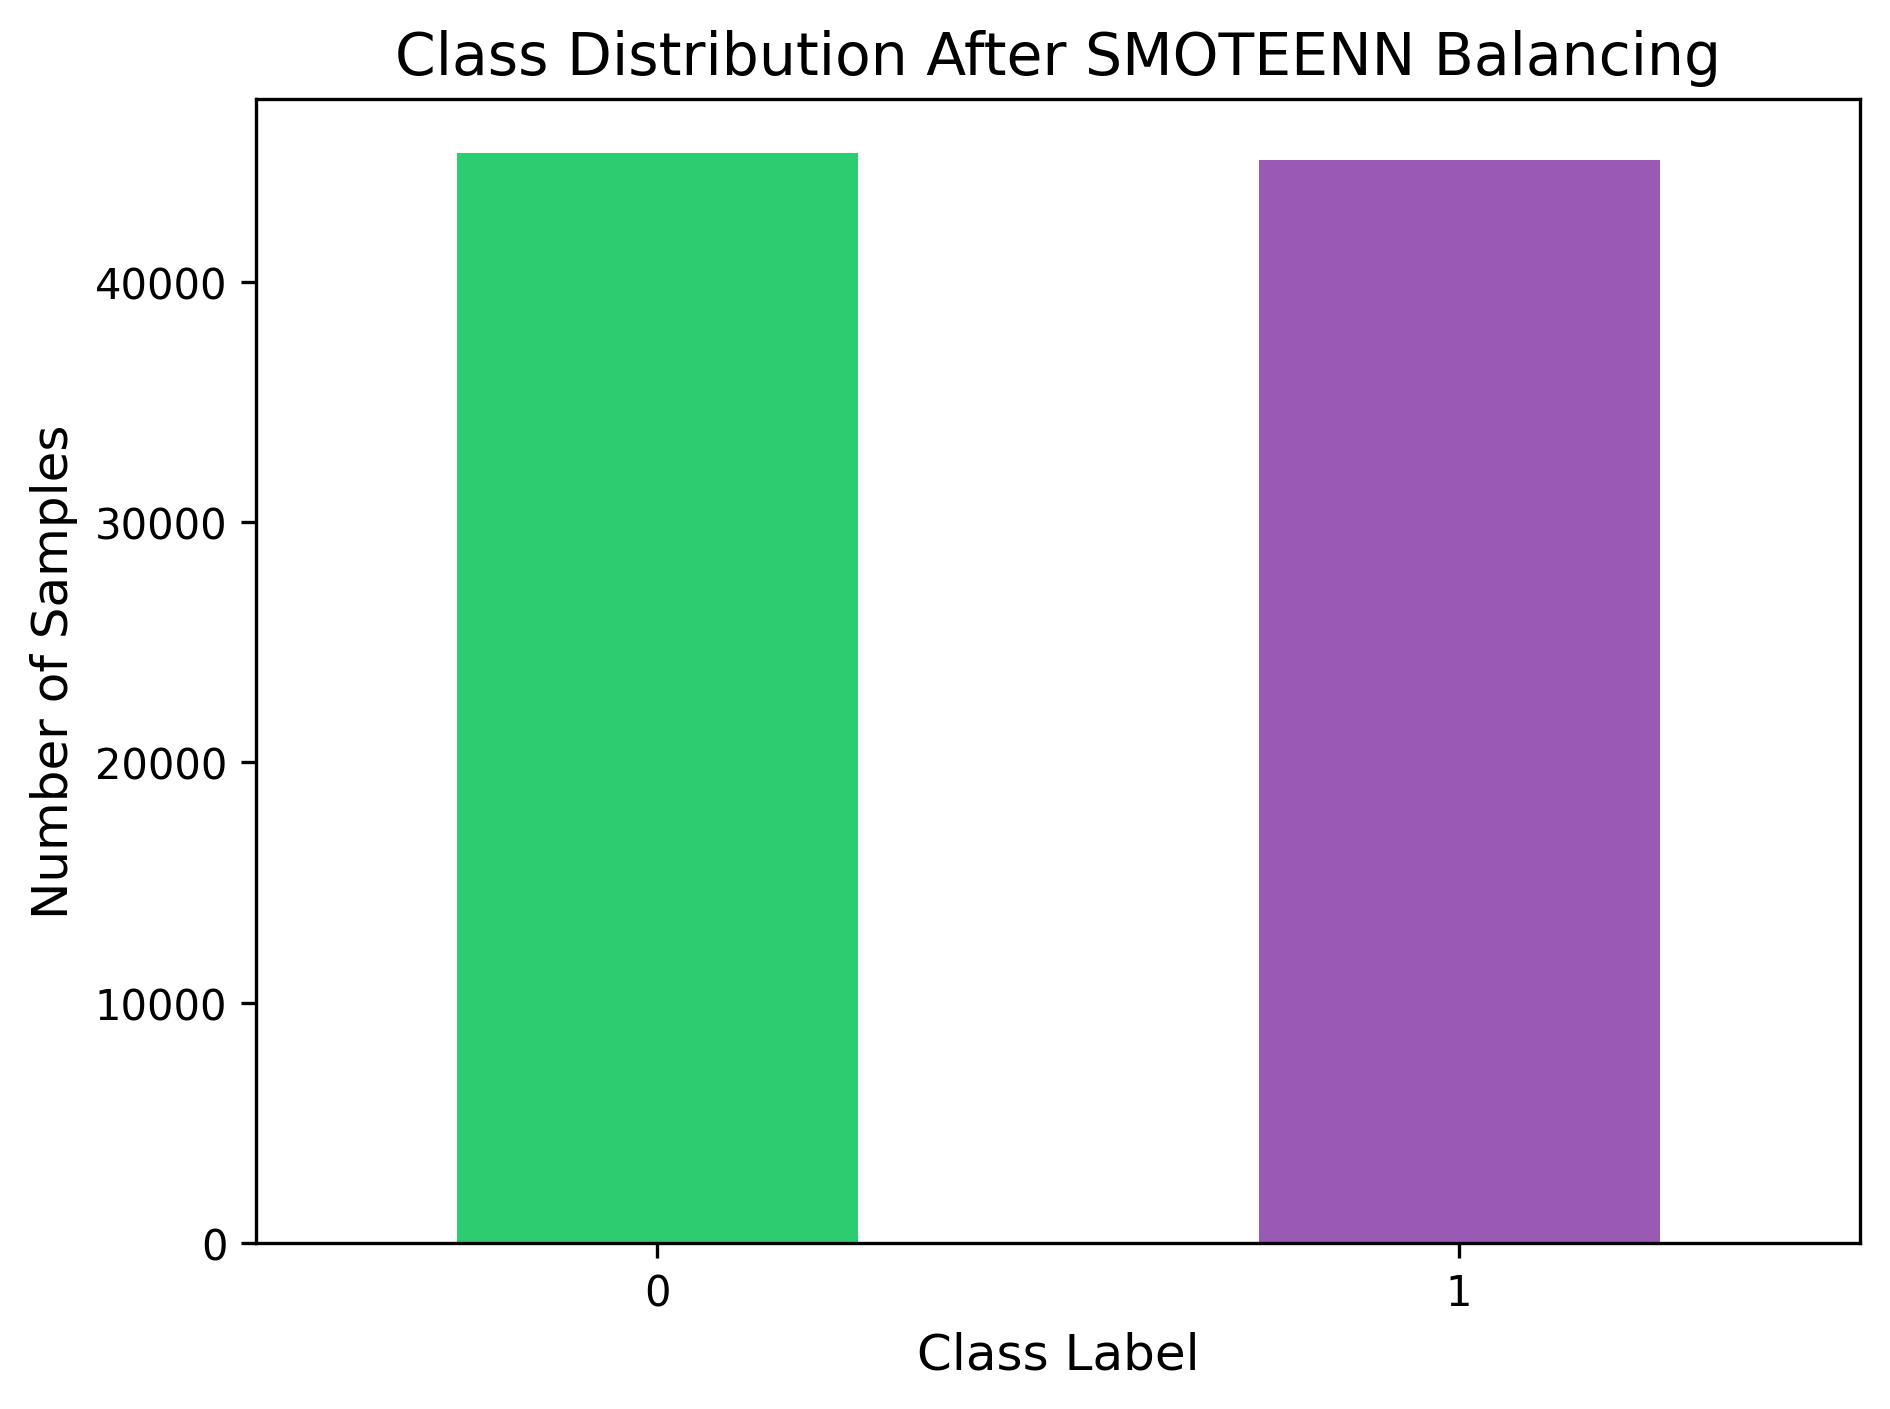

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.combine import SMOTEENN

# Load dataset
df = pd.read_csv('/content/stroke_risk_dataset.csv')

# ---------------- BEFORE BALANCING ----------------
counts_before = df['At Risk (Binary)'].value_counts()

plt.figure(dpi=300)
counts_before.plot(
    kind='bar',
    color=['#e74c3c', '#3498db']
)
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Class Distribution Before Balancing', fontsize=14)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# Save high-resolution figure
plt.savefig(
    "a1.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

# ---------------- APPLY BALANCING ----------------
X = df.drop(columns=['At Risk (Binary)'])
y = df['At Risk (Binary)']

# New / Hybrid Balancing Technique
smote_enn = SMOTEENN(random_state=42)
X_bal, y_bal = smote_enn.fit_resample(X, y)

# ---------------- AFTER BALANCING ----------------
counts_after = y_bal.value_counts()

plt.figure(dpi=300)
counts_after.plot(
    kind='bar',
    color=['#2ecc71', '#9b59b6']
)
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Class Distribution After SMOTEENN Balancing', fontsize=14)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# Save high-resolution figure
plt.savefig(
    "a2.png",
    dpi=300,
    bbox_inches="tight")
plt.show()


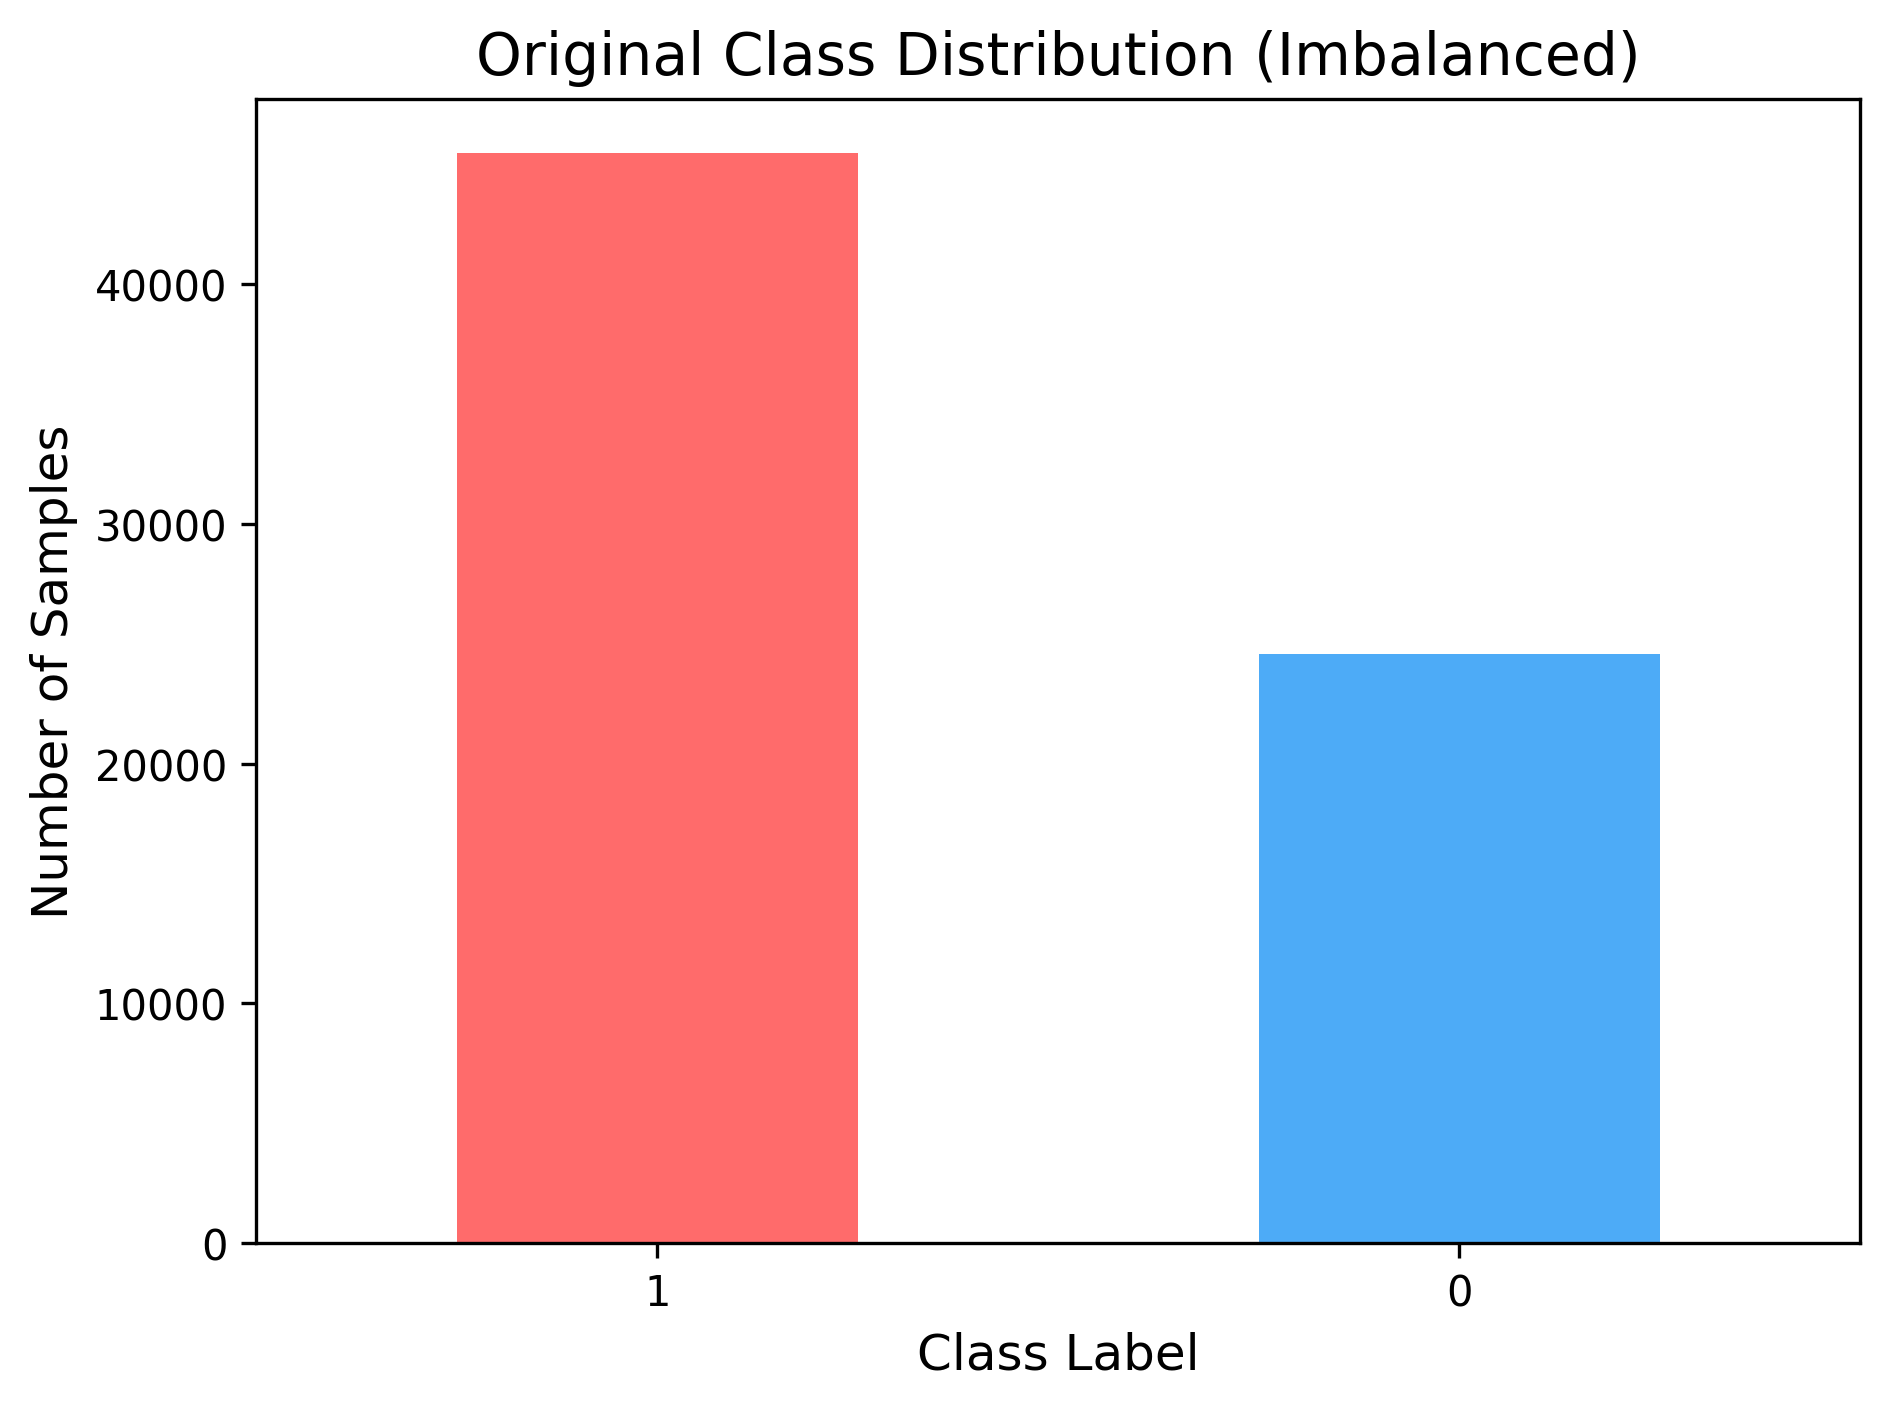

<Figure size 640x480 with 0 Axes>

Class Weights: {np.int64(0): np.float64(1.4253135689851768), np.int64(1): np.float64(0.7701786814540974)}


<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

# Load dataset
df = pd.read_csv('/content/stroke_risk_dataset.csv')

X = df.drop(columns=['At Risk (Binary)'])
y = df['At Risk (Binary)']

# ---------------- CLASS DISTRIBUTION ----------------
counts = y.value_counts()

plt.figure(dpi=300)
counts.plot(kind='bar', color=['#ff6b6b', '#4dabf7'])
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Original Class Distribution (Imbalanced)', fontsize=14)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
plt.savefig(
    "a1.png",
    dpi=300,
    bbox_inches="tight")
plt.show()
# ---------------- WEIGHTED FOCAL BALANCING ----------------
# Compute class weights
classes = np.unique(y)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y
)

class_weight_dict = {
    classes[i]: class_weights[i] for i in range(len(classes))
}

print("Class Weights:", class_weight_dict)
plt.savefig(
    "a2.png",
    dpi=300,
    bbox_inches="tight")
plt.show()